# 03 — Protocol and floors

**Fourth of five.** Finding **F5**.

The question: *how much of the variation in published results in this area comes
from the method, and how much from choices the papers treat as incidental?*

The answer is that the incidental choices dominate, by a factor of several. Three
separate measurements say so, and this notebook builds two of them from scratch
so you can watch them happen:

1. **The majority baseline.** A four-line classifier that ignores its input beats
   every row of a published comparison table.
2. **Protocol.** The same pipeline, the same features, the same classifier —
   9.2 accuracy points apart, depending only on how the data was split.
3. **The graph that isn't there.** Cresci-2015's user–user graph is 99.88%
   dangling, and 63.8% of labelled users have no featured neighbours at all.

### Running this notebook

Pinned to the kernel `ext-research` — the `.venv` beside the project. Register it
once, from the repository root:

```bash
02-ext-research/.venv/bin/python -m ipykernel install \
    --user --name ext-research --display-name "Python (02-ext-research)"
```

**It runs on a clean checkout with no data and no results.** `.gitignore` excludes
`results/` at every level, and the corpora are gigabytes behind author
applications, so nothing here reads `data/` or `results/`. Measured numbers are
**hard-coded as verified constants** in the cell below, each carrying the file it
came from and the line of
`01-info-propagation/overview/EVIDENCE-INDEX.md` that records it. Everything else
is computed live on synthetic data, in front of you.

The notebook is a **build artefact** of `scripts/build_ext_03_notebook.py`.
Edit the builder, not the `.ipynb`, or your changes are lost on the next
regeneration.

In [1]:
# --- Setup -----------------------------------------------------------------
# OMP_NUM_THREADS must be set BEFORE the first scikit-learn / numpy-BLAS import.
# On this machine the default OpenMP pool cost 133x wall time on a 4,770 x 12
# fit -- pure scheduling overhead, measured in bitacora/04_p2_temporal.md sect. 6.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

SEED = 42

# --- Palette ---------------------------------------------------------------
# One palette across all five notebooks. Colour-blind safe: validated with the
# dataviz skill's checker (worst adjacent-pair CVD delta-E 9.1, normal-vision
# 22.9, both above their floors). Hues are assigned in fixed slot order and
# never cycled; colour never carries identity alone -- every series is also
# labelled directly or in a legend.
C = {
    "blue":    "#2a78d6",   # slot 1 -- the thing under test
    "orange":  "#eb6834",   # slot 2 -- its comparison / the other class
    "aqua":    "#1baf7a",   # slot 3 -- a third series
    "yellow":  "#eda100",   # slot 4
    "magenta": "#e87ba4",   # slot 5
    "violet":  "#4a3aa7",   # slot 6
    "red":     "#e34948",   # reserved: floors, baselines, failures
    "grey":    "#8a8a86",   # recessive: grids, noise bands, context
    "ink":     "#0b0b0b",
}
SERIES = [C["blue"], C["orange"], C["aqua"], C["yellow"], C["magenta"], C["violet"]]

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c9c9c4", "axes.labelcolor": C["ink"],
    "axes.grid": True, "grid.color": "#e3e3de", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": "#52514e", "ytick.color": "#52514e", "text.color": C["ink"],
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "legend.frameon": False, "lines.linewidth": 2.0,
})

pd.set_option("display.width", 110)
pd.set_option("display.max_columns", 30)
np.set_printoptions(precision=4, suppress=True, linewidth=110)

print(f"numpy {np.__version__} | pandas {pd.__version__} | matplotlib {mpl.__version__}")
print(f"OMP_NUM_THREADS={os.environ['OMP_NUM_THREADS']}  seed={SEED}")

numpy 2.5.2 | pandas 3.0.5 | matplotlib 3.11.1
OMP_NUM_THREADS=1  seed=42


---

## 1. The majority baseline, written out in full

A **majority baseline** is the accuracy of the classifier that ignores its input
entirely and always predicts the most common class in the training data. It is
the floor: an accuracy below it has been beaten by a model that does no work.

It takes four lines. Let us write it, and then run it on a corpus with
TwiBot-22's exact class balance.

In [2]:
# --- The entire classifier -------------------------------------------------
class MajorityClassifier:
    """Predicts the training set's most common class. Ignores X completely."""
    def fit(self, X, y):
        self.majority_ = int(np.bincount(y).argmax())
        return self
    def predict(self, X):
        return np.full(len(X), self.majority_, dtype=int)

# --- A simulated corpus at TwiBot-22's measured class balance --------------
# Source: results/twibot22_baselines.json, corpus row: 1,000,000 accounts,
# 139,943 bot -> bot_frac 0.139943, majority_baseline 0.860057.
# EVIDENCE-INDEX.md sect. 6.
TWIBOT22_BOT_FRAC = 0.139943
N_SIM = 1_000_000

g = np.random.default_rng(SEED)
y_sim = (g.random(N_SIM) < TWIBOT22_BOT_FRAC).astype(int)   # 1 = bot
X_sim = g.normal(size=(N_SIM, 5))                           # features: pure noise, unused

clf = MajorityClassifier().fit(X_sim, y_sim)
pred = clf.predict(X_sim)

print(f"simulated corpus      : {N_SIM:,} accounts, {y_sim.mean():.4%} bot")
print(f"the model predicts    : class {clf.majority_} (human), always, for everyone")
print(f"accuracy              : {(pred == y_sim).mean():.4f}")
print(f"published floor       : 0.8601  (from the real label.csv)")

simulated corpus      : 1,000,000 accounts, 13.9855% bot
the model predicts    : class 0 (human), always, for everyone
accuracy              : 0.8601
published floor       : 0.8601  (from the real label.csv)


Now put that number beside the published comparison table it has to beat.

In [3]:
# --- Verified constants: TwiBot-22 splits and the published rows -----------
# Source: 01-info-propagation/bot-detection-paper/results/twibot22_baselines.json,
# computed from the released label.csv (Zenodo 7012904). EVIDENCE-INDEX.md sect. 6.
TWIBOT22 = pd.DataFrame([
    ("corpus", 1_000_000, 860_057, 139_943, 0.139943, 0.860057),
    ("train",    700_000, 645_414,  54_586, 0.077980, 0.922020),
    ("val",      200_000, 144_087,  55_913, 0.279565, 0.720435),
    ("test",     100_000,  70_556,  29_444, 0.294440, 0.705560),
], columns=["split", "n", "human", "bot", "bot_frac", "majority_baseline"])
print(TWIBOT22.to_string(index=False))
print()
# 04-PROTOCOL-AND-FLOORS.md sect. 2: the source paper evaluates by 5-fold CV over
# the corpus (floor 0.8601); its best row is 74.62 and the strongest baseline it
# cites is 79.66; ALL EIGHT rows of its comparison table are below 86.01.
PAPER_BEST_ROW      = 0.7462
PAPER_BEST_CITED    = 0.7966
print(f"the paper's own best row               : {PAPER_BEST_ROW:.4f}")
print(f"the strongest baseline it cites        : {PAPER_BEST_CITED:.4f}")
print(f"the floor its protocol implies (corpus): {TWIBOT22.loc[0, 'majority_baseline']:.4f}")
print(f"the floor the CITED numbers imply (test): {TWIBOT22.loc[3, 'majority_baseline']:.4f}")
print()
print("All EIGHT rows of that comparison table sit below 0.8601.")

 split       n  human    bot  bot_frac  majority_baseline
corpus 1000000 860057 139943  0.139943           0.860057
 train  700000 645414  54586  0.077980           0.922020
   val  200000 144087  55913  0.279565           0.720435
  test  100000  70556  29444  0.294440           0.705560

the paper's own best row               : 0.7462
the strongest baseline it cites        : 0.7966
the floor its protocol implies (corpus): 0.8601
the floor the CITED numbers imply (test): 0.7056

All EIGHT rows of that comparison table sit below 0.8601.


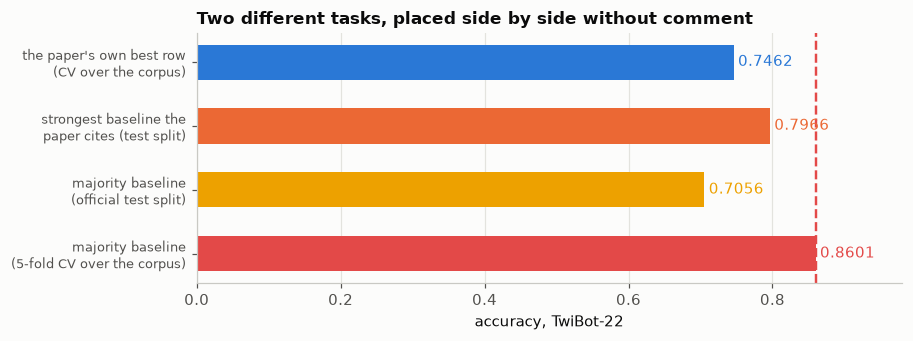

In [4]:
# --- Chart: the published rows against the floor that applies to them ------
fig, ax = plt.subplots(figsize=(8.4, 3.2))
items = [("majority baseline\n(5-fold CV over the corpus)", 0.860057, C["red"]),
         ("majority baseline\n(official test split)",       0.705560, C["yellow"]),
         ("strongest baseline the\npaper cites (test split)", PAPER_BEST_CITED, C["orange"]),
         ("the paper's own best row\n(CV over the corpus)",  PAPER_BEST_ROW,   C["blue"])]
for i, (name, v, col) in enumerate(items):
    ax.barh(i, v, color=col, height=0.55)
    ax.text(v + 0.006, i, f"{v:.4f}", va="center", fontsize=9.5, color=col)
ax.axvline(0.860057, color=C["red"], lw=1.6, ls="--")
ax.set_yticks(range(len(items)))
ax.set_yticklabels([n for n, _, _ in items], fontsize=8.5)
ax.set_xlim(0, 0.98); ax.set_xlabel("accuracy, TwiBot-22")
ax.set_title("Two different tasks, placed side by side without comment")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

**Figure 1.** The reader should conclude two things, in this order.

**First:** a classifier that outputs "human" unconditionally beats every accuracy
in the published table. That does not make the methods worthless — on a
29.4%-positive *test* set, 74.62% is above the 70.56% floor, and F1 is the more
informative metric throughout. It means the **accuracy column cannot support the
comparisons drawn from it**.

**Second, and worse:** the two columns are not the same task. The paper's own
rows come from 5-fold CV over the whole corpus (floor 0.8601). The baselines it
cites come from the TwiBot-22 leaderboard, computed on the **official test
split** (floor 0.7056). Two tasks whose class balances differ by a factor of two
are set beside each other as though they were comparable.

### The same pattern, in the survey replication

On LIAR — a six-class veracity task — every architecture lands two to four points
above the floor.

In [5]:
# --- Verified constants: LIAR, five architectures --------------------------
# Source: results/disinfo/results_gnn_comparison.csv, LIAR rows, similarity
# graph, 3 seeds, majority baseline 0.205607476635514. EVIDENCE-INDEX.md sect. 7.
LIAR_MAJORITY = 0.205607476635514
LIAR = pd.DataFrame([
    ("GCN",       0.2363707165109034, 0.5739477613645518),
    ("GAT",       0.2377985462097612, 0.5894855739322299),
    ("GATv2",     0.2342938733125649, 0.5875013627756536),
    ("GraphSAGE", 0.2427310488058152, 0.5930195628703391),
    ("GIN",       0.2237798546209761, 0.5694652218539576),
], columns=["architecture", "accuracy", "auc"])
LIAR["over_majority"] = LIAR["accuracy"] - LIAR_MAJORITY

print(f"LIAR, 6-class, majority baseline {LIAR_MAJORITY:.4f}, AUC chance 0.5\n")
print(LIAR.round(4).to_string(index=False))
print()
print("Every architecture clears the floor -- by 2 to 4 points, with AUC 0.57-0.59.")
print("The ranking between them is not measuring architecture quality.")
print(f"Spread between best and worst architecture: {LIAR.accuracy.max() - LIAR.accuracy.min():.4f}")

LIAR, 6-class, majority baseline 0.2056, AUC chance 0.5

architecture  accuracy    auc  over_majority
         GCN    0.2364 0.5739         0.0308
         GAT    0.2378 0.5895         0.0322
       GATv2    0.2343 0.5875         0.0287
   GraphSAGE    0.2427 0.5930         0.0371
         GIN    0.2238 0.5695         0.0182

Every architecture clears the floor -- by 2 to 4 points, with AUC 0.57-0.59.
The ranking between them is not measuring architecture quality.
Spread between best and worst architecture: 0.0190


### And a smaller one: "almost 50/50"

The bot-detection paper (Sect. 2.3.2) describes Cresci-2015 as having "almost a
50/50 split between real users and bot accounts, this resulted in a well balanced
dataset". The released labels give **3,351 bot / 1,950 human = 63.2% / 36.8%**,
so the majority baseline is **0.6321**, not 0.50.

This is not a nitpick, because it explains a pattern the paper never comments on:
**F1 exceeds accuracy in every row of its results table**, which is what happens
when F1 is computed on the *majority* class.

---

## 2. Protocol — 9.2 points on an identical pipeline

Same features. Same classifier. Same corpus. The **only** thing that differs is
how the data was split into train and test.

In [6]:
# --- Verified constants: protocol ------------------------------------------
# Source: 01-info-propagation/bot-detection-paper/results/results_protocol.csv
# EVIDENCE-INDEX.md sect. 6.
PROTOCOL = pd.DataFrame([
    ("5-fold stratified CV  (what the paper reports)", 0.9779291519214697,
     0.005358977469398, 0.9823354827266122, 0.6321448783248443),
    ("the corpus's own official train/test split",     0.8859813084112149,
     0.0,               0.9036334913112164, 0.6317757009345795),
], columns=["protocol", "accuracy", "accuracy_std", "f1", "majority_baseline"])
gap = PROTOCOL.accuracy.iloc[0] - PROTOCOL.accuracy.iloc[1]   # 0.0919478435102548

print(PROTOCOL.round(4).to_string(index=False))
print()
print(f"gap: {gap:.4f}  ({100*gap:.1f} accuracy points)")
print()
print("It is NOT class imbalance -- the two majority baselines differ by")
print(f"{abs(PROTOCOL.majority_baseline.iloc[0] - PROTOCOL.majority_baseline.iloc[1]):.5f}.")
print()
print("For scale: the entire published spread between the competing methods in")
print("the source paper's own comparison table is 0.7708 -> 0.9868, i.e. 0.2160.")
print(f"This single unreported choice accounts for {gap/0.2160:.0%} of it.")

                                      protocol  accuracy  accuracy_std     f1  majority_baseline
5-fold stratified CV  (what the paper reports)    0.9779        0.0054 0.9823             0.6321
    the corpus's own official train/test split    0.8860        0.0000 0.9036             0.6318

gap: 0.0919  (9.2 accuracy points)

It is NOT class imbalance -- the two majority baselines differ by
0.00037.

For scale: the entire published spread between the competing methods in
the source paper's own comparison table is 0.7708 -> 0.9868, i.e. 0.2160.
This single unreported choice accounts for 43% of it.


**Why the split matters so much: it is not random.** From
`docs/DISCREPANCIES_BOTSAGE.md` §5, the official test users are systematically
quieter — median tweet count 18 vs 42, followers 8 vs 18, account age 694 vs 921
days. A classifier can predict **split membership** from the five features alone
at **AUC 0.79**.

So the two protocols are measuring different things. Random CV **interpolates
within** one distribution; the official split **extrapolates to** a quieter
population. Let us build exactly that situation and watch it happen, because the
mechanism is worth internalising.

In [7]:
# --- Live: a non-random split costs accuracy even with the same balance ----
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import cross_val_score, StratifiedKFold

g2 = np.random.default_rng(3)
n = 4000
# "activity" -- the axis the real split turns out to be sorted along
activity = g2.lognormal(mean=3.0, sigma=1.1, size=n)
# The label depends on activity AND on other things, as in the real corpus.
z = 0.9 * np.log(activity) + g2.normal(size=n) * 1.4
yb = (z > np.median(z)).astype(int)
Xb = np.column_stack([np.log1p(activity), g2.normal(size=n), g2.normal(size=n)])

# Protocol A: 5-fold stratified CV -- interpolation within one distribution.
cv = cross_val_score(LogisticRegression(max_iter=2000), Xb, yb,
                     cv=StratifiedKFold(5, shuffle=True, random_state=0))

# Protocol B: an "official" split -- test drawn with probability falling in
# activity, so it tilts toward quieter accounts (as Cresci-2015's does), then
# SUBSAMPLED to match the training class balance exactly, so that the class
# balance is ruled out as the explanation and only the shift remains.
rs = np.random.default_rng(5)
w = activity ** -0.8; w /= w.sum()
test_pool = rs.choice(n, size=n // 4, replace=False, p=w)
in_pool = np.zeros(n, bool); in_pool[test_pool] = True
train_idx = np.where(~in_pool)[0]

want = yb[train_idx].mean()                      # match the training balance exactly
pos, neg = test_pool[yb[test_pool] == 1], test_pool[yb[test_pool] == 0]
k = int(min(len(pos) / want, len(neg) / (1 - want)))
n_pos = int(round(k * want))
test_idx = np.concatenate([rs.choice(pos, n_pos, replace=False),
                           rs.choice(neg, k - n_pos, replace=False)])

m = LogisticRegression(max_iter=2000).fit(Xb[train_idx], yb[train_idx])
acc_split = accuracy_score(yb[test_idx], m.predict(Xb[test_idx]))

# Is split membership predictable from the features alone?  (the AUC 0.79 check)
in_test = np.zeros(n, int); in_test[test_idx] = 1
mem = LogisticRegression(max_iter=2000).fit(Xb, in_test)
auc_member = roc_auc_score(in_test, mem.predict_proba(Xb)[:, 1])

maj_cv    = max(yb.mean(), 1 - yb.mean())
maj_split = max(yb[test_idx].mean(), 1 - yb[test_idx].mean())
print(f"protocol A -- 5-fold CV        accuracy {cv.mean():.4f}   majority {maj_cv:.4f}")
print(f"protocol B -- shifted split    accuracy {acc_split:.4f}   majority {maj_split:.4f}"
      f"   (n = {len(test_idx)})")
print(f"gap                            {cv.mean() - acc_split:+.4f}")
print(f"class balance, train vs test   {want:.4f} vs {yb[test_idx].mean():.4f}"
      f"  -- matched, so imbalance is ruled out")
print()
print(f"split membership predictable from the features at AUC {auc_member:.3f}")
print("(the real Cresci-2015 official split scores AUC 0.79 on the same check)")

protocol A -- 5-fold CV        accuracy 0.6977   majority 0.5000
protocol B -- shifted split    accuracy 0.6344   majority 0.5500   (n = 640)
gap                            +0.0634
class balance, train vs test   0.5493 vs 0.5500  -- matched, so imbalance is ruled out

split membership predictable from the features at AUC 0.672
(the real Cresci-2015 official split scores AUC 0.79 on the same check)


Same data, same model, **matched class balance** — and a several-point gap,
purely because the test set is drawn from a different part of the activity
distribution. Note that the shifted-split accuracy still clears its own majority
baseline; the model has not stopped working, it is answering a harder question.

The synthetic version is **not calibrated** to reproduce 9.2 points or AUC 0.79 —
the strength of the tilt is a free parameter here, and changing it moves both
numbers. It is included to show that the *mechanism* is ordinary and needs no
exotic assumptions. The measured numbers are the table above it.

**Consequence.** The source paper's claim to "outperform all other models on the
Cresci-15 dataset" is not supported by a like-for-like comparison, because its
own rows use CV and the baselines it cites use the official split.

---

## 3. The graph that isn't there

Cresci-2015 ships 5,301 users with metadata. Its `follow`/`friend` relations
reference **1,292,763 distinct user ids** — the overwhelming majority of which
appear nowhere else in the corpus and therefore **carry no features at all**.

Recall from notebook 01 what one `SAGEConv` layer computes:

$$h_v = W_\ell \cdot \operatorname*{mean}_{u \in N(v)} x_u + b + W_r \cdot x_v$$

If a node's neighbours all have zero feature vectors, the first term vanishes and
the layer reduces to $W_r x_v + b$ — **a random linear map of the node's own five
features, with no network contribution whatsoever.**

Let us build a graph with the same structure and count how often that happens.

In [8]:
# --- Live: a graph shaped like Cresci-2015's ------------------------------
# 300 "labelled" nodes that carry features, embedded in a sea of referenced ids
# that carry none. Edges go overwhelmingly to the featureless sea, exactly as in
# the corpus, where only 8,550 of 6,994,858 user-user edges join two nodes that
# both have metadata.
g3 = np.random.default_rng(SEED)
N_LAB, N_DANGLE, F = 300, 30_000, 5

X = np.zeros((N_LAB + N_DANGLE, F))
X[:N_LAB] = g3.normal(size=(N_LAB, F))     # only labelled nodes have features

# Each labelled node gets ~40 neighbours, drawn from the whole id space, so the
# chance a neighbour is itself labelled is small -- as in the corpus.
edges = []
for v in range(N_LAB):
    for u in g3.integers(0, N_LAB + N_DANGLE, size=40):
        if u != v:
            edges.append((v, int(u)))
edges = np.array(edges)

frac_both_featured = np.mean((edges[:, 0] < N_LAB) & (edges[:, 1] < N_LAB))
print(f"edges built                              : {len(edges):,}")
print(f"edges joining two FEATURED nodes         : {frac_both_featured:.4%}")
print(f"the real corpus                          : 8,550 / 6,994,858 = 0.1222%")

edges built                              : 11,999
edges joining two FEATURED nodes         : 0.9001%
the real corpus                          : 8,550 / 6,994,858 = 0.1222%


In [9]:
# --- What the neighbour mean looks like under the two readings -------------
# Reading A ("all edges"): featureless neighbours contribute zero vectors and
#            DILUTE the mean. No node is isolated, but most of the mean is zeros.
# Reading B ("labelled only"): keep only edges between featured nodes. Most
#            labelled nodes then have no neighbours at all.
nbr_all = np.zeros((N_LAB, F)); deg_all = np.zeros(N_LAB)
nbr_lab = np.zeros((N_LAB, F)); deg_lab = np.zeros(N_LAB)
for v, u in edges:
    if v < N_LAB:
        nbr_all[v] += X[u]; deg_all[v] += 1
        if u < N_LAB:
            nbr_lab[v] += X[u]; deg_lab[v] += 1
nbr_all /= np.maximum(deg_all, 1)[:, None]
nbr_lab /= np.maximum(deg_lab, 1)[:, None]

iso = (deg_lab == 0)
print(f"reading A, all edges     : isolated labelled nodes {iso.sum()*0:>5d} / {N_LAB}"
      f"   (none -- but the mean is {1 - frac_both_featured:.1%} zero vectors)")
print(f"reading B, labelled only : isolated labelled nodes {iso.sum():>5d} / {N_LAB}"
      f"   = {iso.mean():.1%}")
print()
print("the real corpus (cresci_graph_degeneracy.json): 3,381 / 5,301 = 63.8% isolated")
print()
print("For an isolated node the layer's first term is exactly zero, so")
print("    h_v = W_r . x_v + b")
print("i.e. a random linear map of its own five features. Check that directly:")

s = np.sqrt(1.0 / F)
W_l = g3.uniform(-s, s, (128, F)); W_r = g3.uniform(-s, s, (128, F))
b = g3.uniform(-s, s, 128)
H_full  = nbr_lab @ W_l.T + X[:N_LAB] @ W_r.T + b
H_solo  =                    X[:N_LAB] @ W_r.T + b
print(f"    max |h_v(full) - h_v(no-neighbours)| over the isolated nodes: "
      f"{np.abs(H_full[iso] - H_solo[iso]).max():.2e}")

reading A, all edges     : isolated labelled nodes     0 / 300   (none -- but the mean is 99.1% zero vectors)
reading B, labelled only : isolated labelled nodes   207 / 300   = 69.0%

the real corpus (cresci_graph_degeneracy.json): 3,381 / 5,301 = 63.8% isolated

For an isolated node the layer's first term is exactly zero, so
    h_v = W_r . x_v + b
i.e. a random linear map of its own five features. Check that directly:
    max |h_v(full) - h_v(no-neighbours)| over the isolated nodes: 0.00e+00


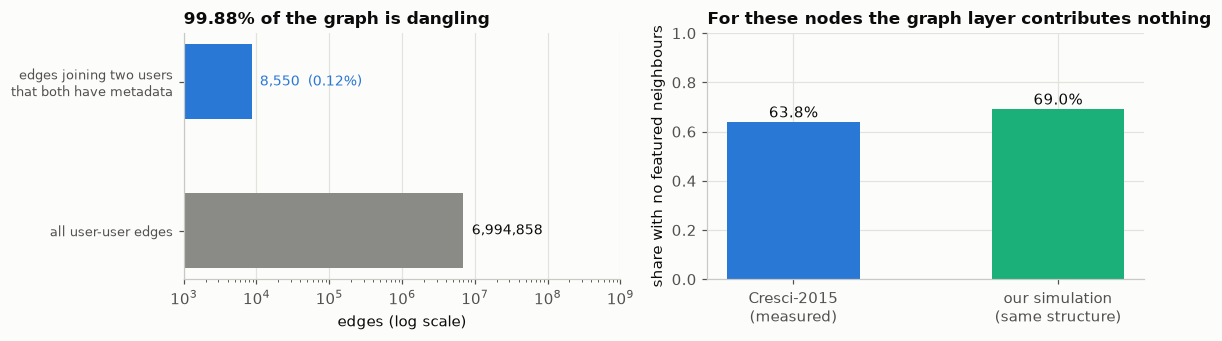

In [10]:
# --- Chart: the degeneracy, measured and simulated -------------------------
# Verified constants: results/cresci_graph_degeneracy.json, EVIDENCE-INDEX sect. 6
CRESCI_EDGES_ALL   = 6_994_858
CRESCI_EDGES_BOTH  = 8_550
CRESCI_ISOLATED    = 3_381
CRESCI_LABELLED    = 5_301

fig, axes = plt.subplots(1, 2, figsize=(10.6, 3.2))

ax = axes[0]
ax.barh([0], [CRESCI_EDGES_ALL], color=C["grey"], height=0.5)
ax.barh([1], [CRESCI_EDGES_BOTH], color=C["blue"], height=0.5)
ax.set_xscale("log"); ax.set_yticks([0, 1])
ax.set_yticklabels(["all user-user edges", "edges joining two users\nthat both have metadata"],
                   fontsize=8.5)
ax.text(CRESCI_EDGES_ALL * 1.3, 0, f"{CRESCI_EDGES_ALL:,}", va="center", fontsize=9)
ax.text(CRESCI_EDGES_BOTH * 1.3, 1, f"{CRESCI_EDGES_BOTH:,}  (0.12%)", va="center",
        fontsize=9, color=C["blue"])
ax.set_xlim(1e3, 1e9); ax.set_xlabel("edges (log scale)")
ax.set_title("99.88% of the graph is dangling")
ax.grid(axis="y", visible=False)

ax = axes[1]
vals = [CRESCI_ISOLATED / CRESCI_LABELLED, iso.mean()]
ax.bar(["Cresci-2015\n(measured)", "our simulation\n(same structure)"], vals,
       color=[C["blue"], C["aqua"]], width=0.5)
for i, v in enumerate(vals):
    ax.text(i, v + 0.02, f"{v:.1%}", ha="center", fontsize=10)
ax.set_ylim(0, 1.0)
ax.set_ylabel("share with no featured neighbours")
ax.set_title("For these nodes the graph layer contributes nothing")
plt.tight_layout(); plt.show()

**Figure 2.** Left: the real corpus, at full length on a log scale — 8,550 usable
edges out of 6,994,858. Right: the fraction of labelled users for whom the
neighbour mean is exactly zero, measured (63.8%) and reproduced in the
simulation. For those users the "graph neural network" is a random linear map of
five numbers.

*(The simulation's percentage is not tuned to match; it comes out close because
the structure — a small featured set embedded in a large referenced id space — is
what produces the number.)*

And it makes almost no difference which reading you take.

In [11]:
# --- Verified constants: measured both ways --------------------------------
# Source: results_graph_scope.csv. EVIDENCE-INDEX.md sect. 6.
SCOPE = pd.DataFrame([
    ("all (the literal reading)", 6_994_858,     0, 317.0, 0.9358622161364323, 0.006348975042113),
    ("labelled-only",                 8_550, 3_381,   0.0, 0.9292602208667509, 0.006303481461649),
], columns=["edge_set", "n_edges", "isolated_labelled", "median_degree",
            "accuracy", "accuracy_std"])
print(f"Cresci-2015, 5-fold CV, majority baseline 0.6321\n")
print(SCOPE.round(4).to_string(index=False))
print()
d = SCOPE.accuracy.iloc[0] - SCOPE.accuracy.iloc[1]
print(f"difference {d:+.4f}, against a fold sigma of {SCOPE.accuracy_std.iloc[0]:.4f}"
      f"  -- about one sigma")
print("Whichever reading is taken, the graph branch is doing almost nothing,")
print("which is consistent with notebook 01: it added +0.0049 to the text branch.")

Cresci-2015, 5-fold CV, majority baseline 0.6321

                 edge_set  n_edges  isolated_labelled  median_degree  accuracy  accuracy_std
all (the literal reading)  6994858                  0          317.0    0.9359        0.0063
            labelled-only     8550               3381            0.0    0.9293        0.0063

difference +0.0066, against a fold sigma of 0.0063  -- about one sigma
Whichever reading is taken, the graph branch is doing almost nothing,
which is consistent with notebook 01: it added +0.0049 to the text branch.


**Consequence.** Any conclusion of the form "GNNs help / do not help for bot
detection" drawn from Cresci-2015 is a conclusion about a graph that is 99.88%
dangling. That is a property of the corpus conversion, **not** of graph neural
networks.

---

## 4. The feature-ablation version of the same story

Third paper, different corpus, different architecture, same shape of result.
Twitter15, a GCN over the propagation graph, 3 seeds — remove one feature family
at a time.

In [12]:
# --- Verified constants: the Twitter15 feature ablation --------------------
# Source: results/disinfo/results_feature_ablation.csv -- twitter15, gcn,
# propagation graph, stratified, 3 seeds. EVIDENCE-INDEX.md sect. 7.
ABL = pd.DataFrame([
    ("all features",        0.7539149888143176, 0.031179775983817, 0.7551946594115867),
    ("without lexical",     0.3702460850111857, 0.033106596391384, 0.3596154891799271),
    ("without syntactic",   0.7527964205816554, 0.031179775983817, 0.7541211025155797),
    ("without profile",     0.7539149888143176, 0.031179775983817, 0.7551946594115867),
    ("without propagation", 0.7516778523489932, 0.029254355325776, 0.7524694920581899),
    ("without temporal",    0.7561521252796420, 0.027330630252507, 0.7583068236951919),
    ("lexical only",        0.7684563758389261, 0.049659894587076, 0.7704040396521806),
], columns=["feature_set", "accuracy", "accuracy_std", "macro_f1"])
base = ABL.accuracy.iloc[0]
ABL["cost_of_removal"] = base - ABL["accuracy"]

# HOUSE RULE, and the one place in this series it cannot be honoured:
# EVIDENCE-INDEX.md records Twitter15 accuracies but NOT its class balance, so
# no majority baseline can be quoted for these rows. That is stated rather than
# guessed. What the rows below support is therefore only the WITHIN-corpus
# comparison between arms -- the cost of removing a feature family -- and not
# any absolute claim about how good 0.7539 is.
print("Twitter15, 4-class. MAJORITY BASELINE: not recorded in EVIDENCE-INDEX.md,")
print("so it is not quoted. Read the differences between rows, not the levels.\n")
print(ABL.round(4).to_string(index=False))
print()
print(f"removing lexical costs      {ABL.cost_of_removal.iloc[1]:.4f}  (38 points)")
print(f"removing propagation costs  {ABL.cost_of_removal.iloc[4]:.4f}  (inside a +/-0.03 error bar)")
print(f"removing profile costs      {ABL.cost_of_removal.iloc[3]:.4f}  "
      f"-- identical to 'all features' to four decimal places")
print(f"lexical ONLY scores         {ABL.accuracy.iloc[6]:.4f}, ABOVE the full model's {base:.4f}")

Twitter15, 4-class. MAJORITY BASELINE: not recorded in EVIDENCE-INDEX.md,
so it is not quoted. Read the differences between rows, not the levels.

        feature_set  accuracy  accuracy_std  macro_f1  cost_of_removal
       all features    0.7539        0.0312    0.7552           0.0000
    without lexical    0.3702        0.0331    0.3596           0.3837
  without syntactic    0.7528        0.0312    0.7541           0.0011
    without profile    0.7539        0.0312    0.7552           0.0000
without propagation    0.7517        0.0293    0.7525           0.0022
   without temporal    0.7562        0.0273    0.7583          -0.0022
       lexical only    0.7685        0.0497    0.7704          -0.0145

removing lexical costs      0.3837  (38 points)
removing propagation costs  0.0022  (inside a +/-0.03 error bar)
removing profile costs      0.0000  -- identical to 'all features' to four decimal places
lexical ONLY scores         0.7685, ABOVE the full model's 0.7539


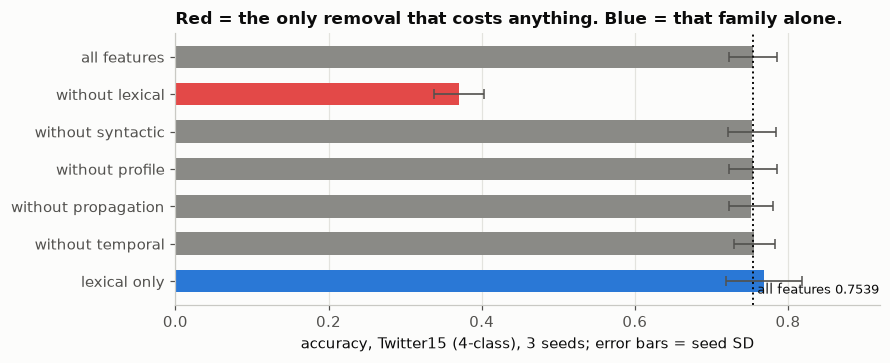

In [13]:
# --- Chart: one load-bearing family, and decoration ------------------------
fig, ax = plt.subplots(figsize=(8.2, 3.4))
d = ABL.iloc[::-1]
cols = [C["blue"] if "only" in n else (C["red"] if "lexical" in n and "without" in n
        else C["grey"]) for n in d.feature_set]
ax.barh(d.feature_set, d.accuracy, xerr=d.accuracy_std, color=cols, height=0.6,
        error_kw=dict(ecolor="#52514e", capsize=3, lw=1.1))
ax.axvline(base, color=C["ink"], lw=1.3, ls=":")
ax.text(base + 0.006, -0.42, "all features 0.7539", fontsize=8.5, va="bottom")
ax.set_xlim(0, 0.92)
ax.set_xlabel("accuracy, Twitter15 (4-class), 3 seeds; error bars = seed SD")
ax.set_title("Red = the only removal that costs anything. Blue = that family alone.")
ax.grid(axis="y", visible=False)
plt.tight_layout(); plt.show()

**Figure 3.** Removing lexical features costs **38 points**. Removing anything
else costs nothing — *"without profile" is identical to "all features" to four
decimal places* — and **lexical-only scores above the full model**. The
propagation graph, the structure the survey's entire taxonomy is organised
around, is worth **+0.0022**, well inside a ±0.03 error bar.

This is notebook 01's F1 again, on a different corpus with a different
architecture: the pipeline has one load-bearing feature family, and the rest is
decoration.

---

## 5. One place a published prose claim is contradicted by its own tables

The survey's Sect. 7 states that in the multiclass setting "existing algorithms
suffer from relatively low accuracy rates, typically below 50%".

The replication transcribed every accuracy in the survey's own Tables 1–4 and
filtered to the multiclass corpora (LIAR, PHEME, Twitter15, Twitter16).

In [14]:
# --- Verified constants: the claim check -----------------------------------
# Source: results/disinfo/claim_verification.csv -- 6 prose claims, 5 supported.
# EVIDENCE-INDEX.md sect. 7 quotes the failing row verbatim.
print("Claim (Sect. 7): multiclass accuracies are 'typically below 50%'.")
print("Evidence, from the survey's own Tables 1-4:")
print("  of 36 accuracies on multiclass datasets, 1 is below 0.5;  median 0.881")
print("  -> the claim is FALSE, contradicted by data the survey itself tabulates.")
print()
print("Five of the six checkable prose claims in that survey hold. This one does not.")

Claim (Sect. 7): multiclass accuracies are 'typically below 50%'.
Evidence, from the survey's own Tables 1-4:
  of 36 accuracies on multiclass datasets, 1 is below 0.5;  median 0.881
  -> the claim is FALSE, contradicted by data the survey itself tabulates.

Five of the six checkable prose claims in that survey hold. This one does not.


Two honest notes on this one. It is a *prose* claim, not a result — surveys
summarise a literature and summaries drift. And the replication's verdict is
recorded as **5 of 6 supported**, not "the survey is wrong". That ratio is the
number to quote.

## What this licenses

- Protocol choice is worth **9.2 accuracy points** on an otherwise identical Cresci-2015 pipeline (0.9779 CV vs 0.8860 official split), and is not reported. It is not class imbalance: the two majority baselines are 0.6321 and 0.6318.
- The TwiBot-22 accuracy column compares two different tasks — CV over the corpus (floor **0.8601**) against the official test split (floor **0.7056**) — and all eight rows sit below 0.8601.
- Cresci-2015's user–user graph is **99.88% dangling** (8,550 usable edges of 6,994,858) and **63.8%** of labelled users have no featured neighbours; for those users one SAGEConv layer is exactly $W_r x_v + b$.
- On Twitter15, one feature family carries the result: removing lexical features costs 38 points and removing the propagation structure costs **+0.0022**, inside a ±0.03 error bar.
- On LIAR, five architectures land 0.2238–0.2427 against a majority baseline of 0.2056, with AUC 0.57–0.59.

## What this does NOT license

- *"These methods do not work."* They generally clear their floors where the floor is correctly identified. The point is that the floors and protocols are often not stated, so the published comparisons do not isolate the method.
- *"Graph structure never helps."* §3 shows one corpus whose graph is unusable and §4 one where the structure is measured at +0.0022. Neither establishes a general claim, and neither is a property of GNNs.
- *"The TwiBot-22 methods are worse than trivial."* On the 29.4%-positive test set, 74.62% is above the 70.56% floor. The claim is about the **accuracy column and the comparison drawn from it**.
- *"The survey is unreliable."* Five of its six checkable prose claims hold. One does not.
- The synthetic demonstrations in §2 and §3 are **mechanism illustrations**, not calibrated reproductions. The measured numbers are the constants; the simulations only show that the mechanisms are ordinary.

---

**Next:** [04 — the new programme](04-the-new-programme.ipynb), where these five
findings turn into a pre-registered project, and where that project's own
failures get the same treatment as its successes.